<div style="text-align: center; margin-top: 250px;">
   
<h1 style="text-align: center;">Chicago Food Establishment Inspections</h1>

<p style="text-align: center;">
Ali Khalid<br>
Department of Data Science, Arizona State University<br>
DAT 301: Exploring Data in R and Python<br>
Dr. Neha Joshi<br>
May 3, 2026
</p>

</div>

<div style="page-break-before: always;"></div>

## Introduction

This project uses the Chicago Food Inspections dataset (July 1, 2018 – April 12, 2026) to compare inspection outcomes and violation patterns across three major food establishment types: restaurants, grocery stores, and schools.

My Project 1 focused only on restaurant inspections. This project broadens that analysis by using a three-facility-type comparison to examine inspection results, recorded violations, annual fail rates, and annual inspection counts.

These facility types were selected because they are the three largest categories after filtering to the main inspection outcomes. They also represent three distinct food service settings: commercial (Restaurant), retail (Grocery Store), and institutional (School).

Because this dataset is large, statistical significance alone may not show whether a difference is practically meaningful. Therefore, this analysis also considers practical differences, effect size, test assumptions, and post-hoc comparisons where appropriate.

## Research Questions

This project's research questions are:

1. How do inspection result distributions differ across restaurants, grocery stores, and schools?
2. How do fail rates and inspection counts vary by facility type over time?
3. How do violation count distributions differ across these facility types?
4. Among inspections that fail, do violation counts differ by facility type?

## Analysis Overview

For this analysis, I will:
- import the Chicago Food Inspections dataset
- focus on restaurants, grocery stores, and schools
- create and prepare variables for analysis
- summarize inspection results and violation counts by facility type
- compare inspection result distributions, annual fail rates, and annual inspection counts by facility type
- compare violation count distributions by facility type
- compare violation counts among failed inspections by facility type
- test whether facility type and inspection result are related
- test whether violation counts differ across facility types
- identify which facility types differ from each other if violation counts differ significantly

## Import Libraries, Functions, & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu, norm
from itertools import combinations

file_path = "Food_Inspections_-_7_1_2018_-_Present_20260415.csv"

inspections = pd.read_csv(file_path, low_memory=False)

This project uses `pandas`, `numpy`, and `matplotlib.pyplot` for data preparation, calculations, and visualizations. Functions from `scipy.stats` and `itertools` were used for statistical testing and post-hoc comparisons.

I used `pandas` to import, clean, and summarize the dataset; `numpy` to create condition-based variables and calculations; `matplotlib.pyplot` to create visualizations; `scipy.stats` to run statistical tests; and `itertools` to create pairwise facility-type comparisons.

## Clean Data

In [2]:
main_results = ["Pass", "Pass w/ Conditions", "Fail"]
selected_facilities = ["Restaurant", "Grocery Store", "School"]

food = inspections.copy()

food = food.drop_duplicates(subset="Inspection ID")

food = food[
    (food["Results"].isin(main_results)) &
    (food["Facility Type"].isin(selected_facilities))
].copy()

The dataset was narrowed to restaurants, grocery stores, and schools. Duplicate inspection IDs were removed. Only the three main inspection result categories (Pass, Pass w/ Conditions, and Fail) were kept.

I used `.copy()` to create a separate working dataset before applying filters and creating new variables.

This keeps the project focused on a clear comparison across three major facility types with enough observations to support stable comparisons.

## Create and Prepare Variables

In [3]:
food["Inspection Date"] = pd.to_datetime(food["Inspection Date"], errors="coerce")
food["inspection_year"] = food["Inspection Date"].dt.year

food["violation_count"] = np.where(
    food["Violations"].isna() | (food["Violations"].astype(str).str.strip() == ""),
    0,
    food["Violations"].astype(str).str.count(r"\|") + 1
)

food["facility_type_group"] = pd.Categorical(
    food["Facility Type"],
    categories = selected_facilities,
    ordered = True
)

food["failed_inspection"] = np.where(food["Results"] == "Fail", 1, 0)

food["Results"] = pd.Categorical(
    food["Results"],
    categories = ["Pass", "Pass w/ Conditions", "Fail"],
    ordered = True
)

To make the inspections easier to summarize, compare, and analyze:

I created:

- `inspection_year`: the year extracted from the inspection date
- `violation_count`: the number of recorded violations
- `facility_type_group`: the selected facility type
- `failed_inspection`: whether the inspection failed

I prepared:

- `Inspection Date`: the full date of inspection
- `Results`: the ordered inspection result category

<div style="page-break-before: always;"></div>

## Initial Summary

In [4]:
display(pd.crosstab(food["facility_type_group"], food["Results"]))
food.groupby("facility_type_group", observed = True)["violation_count"].describe()

Results,Pass,Pass w/ Conditions,Fail
facility_type_group,,,
Restaurant,38768,21680,17511
Grocery Store,5468,3409,3018
School,4965,1162,2078


,count,mean,std,min,25%,50%,75%,max
facility_type_group,,,,,,,,
Restaurant,77959.0,4.529317,4.145988,0.0,1.0,4.0,7.0,40.0
Grocery Store,11895.0,4.633039,4.157619,0.0,1.0,4.0,7.0,34.0
School,8205.0,2.594759,2.478321,0.0,1.0,2.0,4.0,21.0


These summaries show:

- Pass is the most common inspection result for all three facility types.
- Restaurants have the most inspections (77,959), followed by grocery stores (11,895) and schools (8,205).
- 75% of restaurant and grocery store inspections have 7 or fewer recorded violations.
- 75% of school inspections have 4 or fewer recorded violations.

<div style="page-break-before: always;"></div>

## Inspection Results by Facility Type

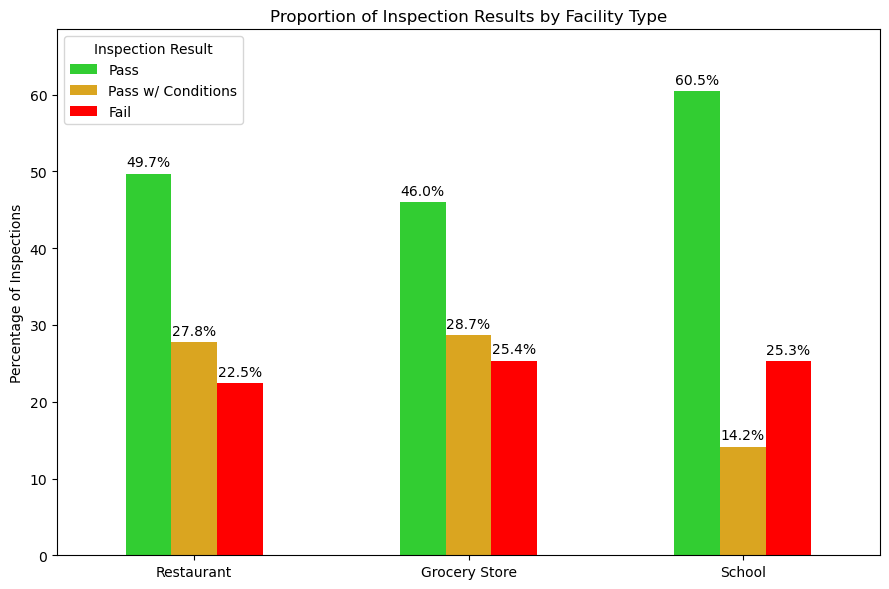

In [5]:
result_counts = pd.crosstab(food["facility_type_group"], food["Results"])

result_percentages = result_counts.div(result_counts.sum(axis = 1), axis = 0) * 100

result_colors = {"Pass": "limegreen", "Pass w/ Conditions": "goldenrod", "Fail": "red"}

ax = result_percentages.plot(kind = "bar", figsize = (9, 6), color = [result_colors[result] for result in result_percentages.columns])

plt.title("Proportion of Inspection Results by Facility Type")
plt.xlabel("")
plt.ylabel("Percentage of Inspections")
plt.xticks(rotation = 0)
plt.legend(title = "Inspection Result")

for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", padding = 3)

plt.ylim(0, result_percentages.to_numpy().max() + 8)

plt.tight_layout()
plt.show()

The grouped bar chart of inspection results by facility type suggests that inspection result distributions differ across the three facility types.

Schools have the largest share of Pass results at 60.5% and a much smaller share of Pass w/ Conditions at 14.2%. However, the school pattern should not be read as simply “better” overall, because its Fail percentage is 25.3%, which is nearly identical to grocery stores at 25.4% and only slightly higher than restaurants at 22.5%.

Together, these percentages suggest that the school pattern is more about what happens among inspections that do not fail than about avoiding failure altogether. The Fail percentages are only about 3 percentage points apart, so schools do not appear to fail much less often than the other facility types. Instead, their passed inspections are more often standard than conditional.

<div style="page-break-before: always;"></div>

## Annual Fail Rate by Facility Type

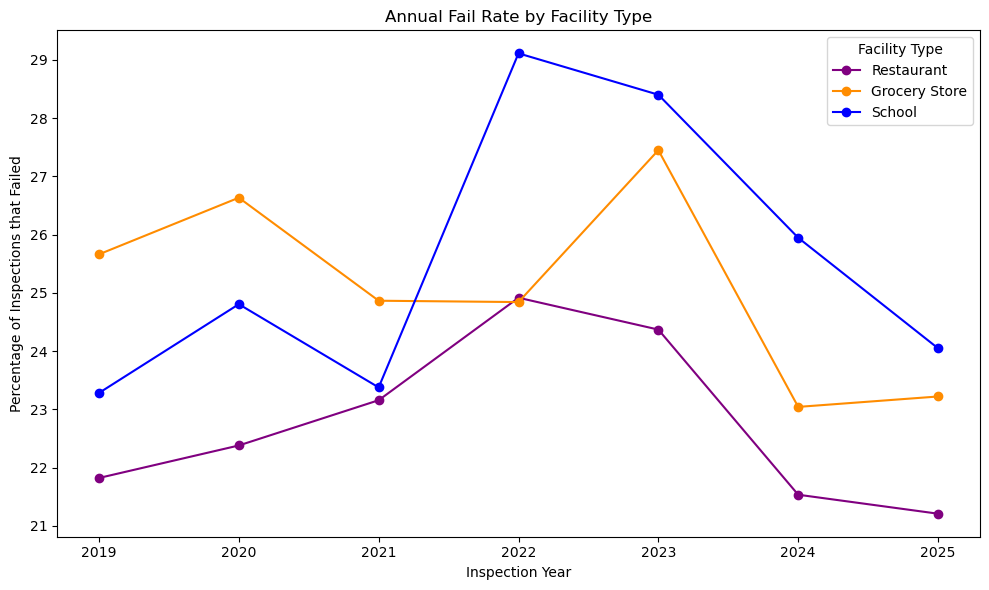

In [6]:
fail_rate_data = food[
    (food["inspection_year"] >= 2019) &
    (food["inspection_year"] <= 2025)
]

fail_rate_by_year = (
    fail_rate_data.groupby(["inspection_year", "facility_type_group"], observed=True)["failed_inspection"]
    .mean()
    .reset_index()
)

fail_rate_by_year["fail_rate_percent"] = fail_rate_by_year["failed_inspection"] * 100

plt.figure(figsize = (10, 6))

facility_colors = {"Restaurant": "purple", "Grocery Store": "darkorange", "School": "blue"}

for facility in selected_facilities:
    subset = fail_rate_by_year[fail_rate_by_year["facility_type_group"] == facility]
    plt.plot(subset["inspection_year"], subset["fail_rate_percent"], 
             marker = "o", label = facility, color = facility_colors[facility])

plt.title("Annual Fail Rate by Facility Type")
plt.xlabel("Inspection Year")
plt.ylabel("Percentage of Inspections that Failed")
plt.xticks(sorted(fail_rate_data["inspection_year"].dropna().unique()))
plt.legend(title = "Facility Type")

plt.tight_layout()
plt.show()

To avoid partial-year comparisons, the line chart of annual fail rate by facility type focuses on complete calendar years from 2019 through 2025.

The chart suggests that fail rates vary by both year and facility type. Across the years shown, restaurants generally have the lowest fail rate, while schools generally have the highest. Schools show the sharpest annual increase, rising noticeably from 2021 to 2022, then declining afterward. In 2022, schools reach the highest point on the chart, while restaurants and grocery stores are closest in fail-rate percentage.

This yearly view shows that the fail-rate pattern is not perfectly stable over time. Although the overall Fail percentages across facility types are close, some years show larger differences or temporary increases. This matters because a facility type that looks only slightly different overall may still have certain years where failed inspections become more common, which could affect how inspection attention or follow-up efforts are prioritized.

<div style="page-break-before: always;"></div>

## Annual Inspection Count by Facility Type

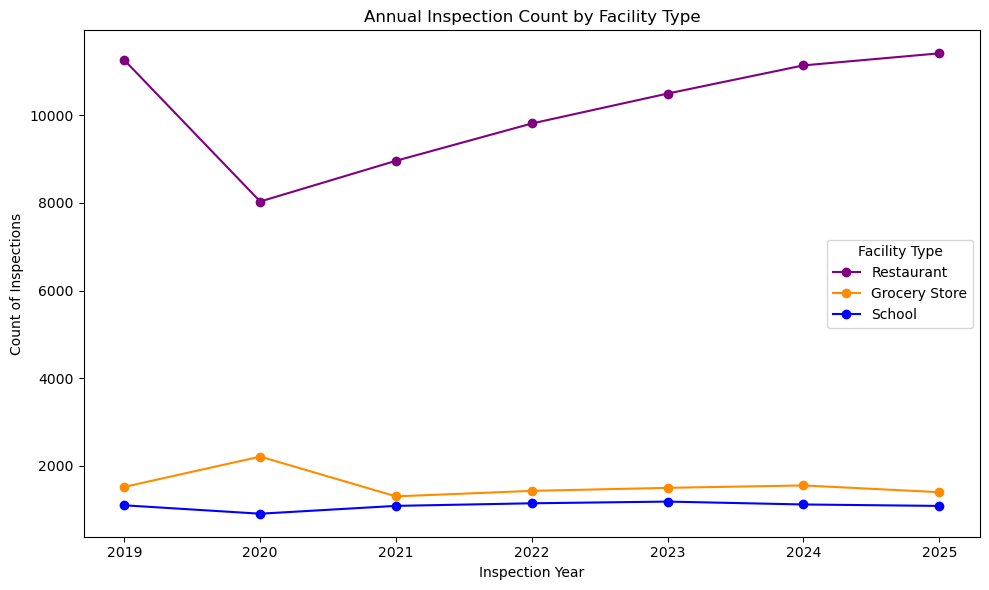

In [7]:
inspection_count_data = food[
    (food["inspection_year"] >= 2019) &
    (food["inspection_year"] <= 2025)
]

inspection_count_by_year = (
    inspection_count_data
    .groupby(["inspection_year", "facility_type_group"], observed=True)
    .size() 
    .reset_index(name = "inspection_count")
)

plt.figure(figsize = (10, 6))

facility_colors = {"Restaurant": "purple", "Grocery Store": "darkorange", "School": "blue"}

for facility in selected_facilities:
    subset = inspection_count_by_year[inspection_count_by_year["facility_type_group"] == facility]
    plt.plot(subset["inspection_year"],subset["inspection_count"],
             marker = "o", label = facility, color = facility_colors[facility])

plt.title("Annual Inspection Count by Facility Type")
plt.xlabel("Inspection Year")
plt.ylabel("Count of Inspections")
plt.xticks(sorted(inspection_count_data["inspection_year"].dropna().unique()))
plt.legend(title = "Facility Type")

plt.tight_layout()
plt.show()

To keep the time comparison consistent, the line chart of annual inspection count by facility type focuses on complete calendar years from 2019 through 2025.

The chart suggests that annual inspection count differs sharply by facility type. In every year shown, restaurants have far more inspections than grocery stores or schools. Restaurant inspection count drops from 2019 to 2020, then increases steadily through 2025, while grocery store and school inspection counts remain much lower and relatively stable.

These count differences are important because the selected facility types are not equally represented in the dataset. Restaurants contribute many more inspection records, so their patterns carry more weight in the overall dataset. Grocery stores and schools have fewer inspections, so their annual percentages can be more sensitive to smaller changes in inspection outcomes. This means inspection percentages, especially fail-rate trends over time, should be interpreted alongside the number of inspections behind them.

<div style="page-break-before: always;"></div>

## Violation Count Distributions by Facility Type

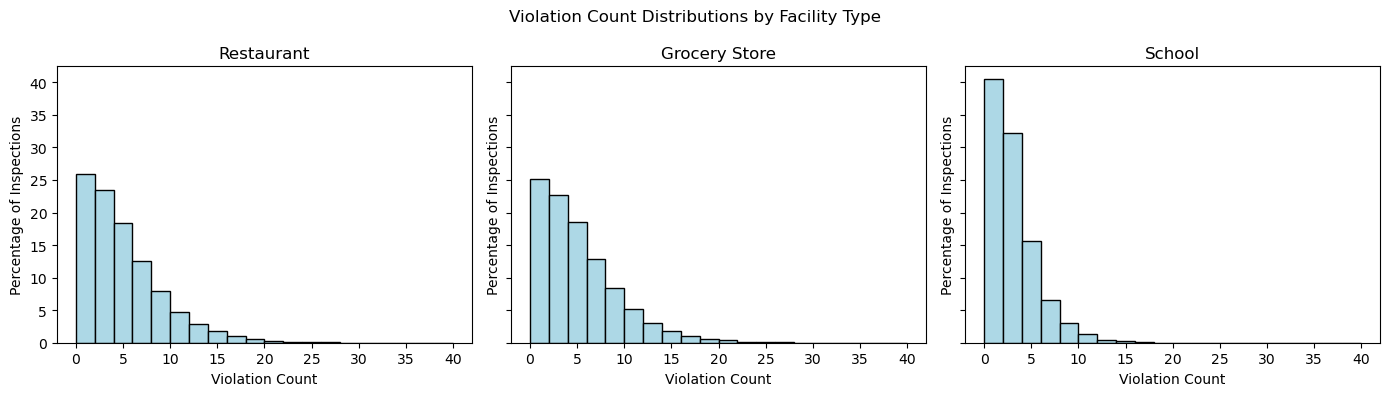

In [8]:
facility_types = ["Restaurant", "Grocery Store", "School"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey = True)

for ax, facility in zip(axes, facility_types):
    subset = food[food["facility_type_group"] == facility]
    
    weights = np.ones(len(subset)) / len(subset) * 100
    
    ax.hist(subset["violation_count"], bins = range(0, 42, 2), 
            weights = weights, color = "lightblue", edgecolor = "black")
    
    ax.set_title(facility)
    ax.set_xlabel("Violation Count")
    ax.set_ylabel("Percentage of Inspections")

plt.suptitle("Violation Count Distributions by Facility Type")
plt.tight_layout()
plt.show()

The histograms of violation count distributions by facility type suggest that violation counts are strongly right-skewed across all three facility types. 

Most inspections are concentrated roughly between 0–5 violations. Restaurants and grocery stores have noticeably similar distribution shapes.

Schools show the strongest low-end concentration, with the tallest peak and shortest right tail. This suggests that higher-violation inspections are less common for schools than for restaurants or grocery stores.

<div style="page-break-before: always;"></div>

## Violation Counts Among Failed Inspections by Facility Type

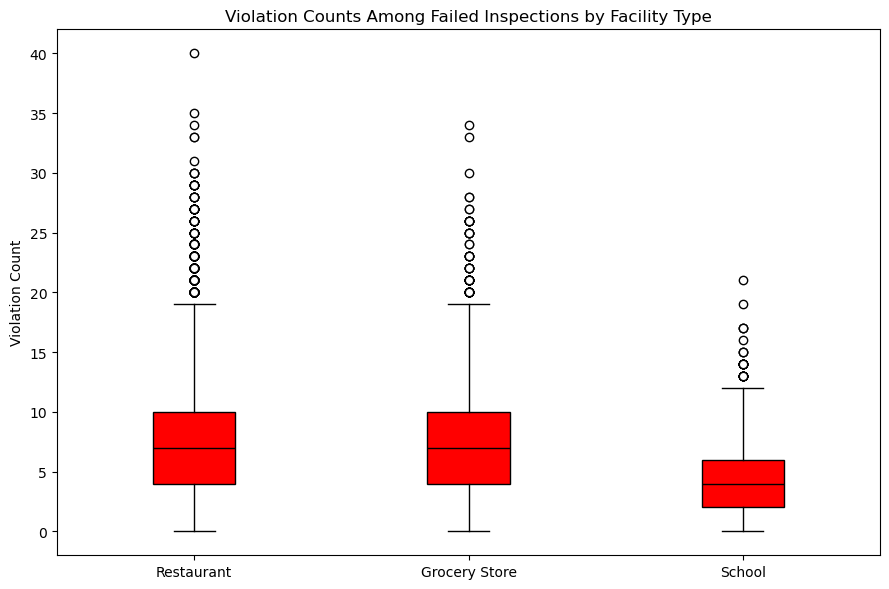

In [9]:
failed_only = food[food["failed_inspection"] == 1]

failed_violation_data = [
    failed_only.loc[
        failed_only["facility_type_group"] == facility,
        "violation_count"
    ]
    for facility in selected_facilities
]

plt.figure(figsize = (9, 6))

plt.boxplot(
    failed_violation_data,
    tick_labels = selected_facilities,
    showfliers = True,
    patch_artist = True,
    boxprops = dict(facecolor = "red", color = "black"),
    medianprops = dict(color = "black", linewidth = 1),
    whiskerprops = dict(color = "black"),
    capprops = dict(color = "black"),
    flierprops = dict(markerfacecolor = "white", markeredgecolor = "black")
)

plt.title("Violation Counts Among Failed Inspections by Facility Type")
plt.xlabel("")
plt.ylabel("Violation Count")

plt.tight_layout()
plt.show()

The box plot of violation counts among failed inspections by facility type suggests that, among inspections that fail, restaurants and grocery stores tend to have higher violation counts than schools. The restaurant and grocery store distributions appear fairly similar, while the school distribution is shifted lower overall.

This adds a severity-focused view of failed inspections. While the grouped bar chart shows the overall share of failed inspections and the annual fail rate line chart shows how fail rates change over time, this chart shows what failure looks like when it occurs. Failed restaurant and grocery store inspections generally involve more violations and more high-count outliers than failed school inspections.

<div style="page-break-before: always;"></div>

## Chi-Square Test: Facility Type and Inspection Result

In [10]:
contingency_table = pd.crosstab(food["facility_type_group"], food["Results"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.to_numpy().sum()
rows, columns = contingency_table.shape
cramers_v = np.sqrt(chi2 / (n * min(rows - 1, columns - 1)))
min_expected = expected.min()

chi_square_summary = pd.DataFrame({
    "Chi-square statistic": [chi2],
    "Degrees of freedom": [dof],
    "p-value": [p_value],
    "Cramer's V": [cramers_v],
    "Minimum expected count": [min_expected]
})

display(chi_square_summary)

,Chi-square statistic,Degrees of freedom,p-value,Cramer's V,Minimum expected count
0,812.242238,4,1.712232e-174,0.064355,1891.620708


The chi-square test results reveal a very small p-value, approximately 1.7e-174, which indicates a statistically significant relationship between facility type and inspection result. 

The chi-square statistic of approximately 812 is far above what we would expect under no relationship for 4 degrees of freedom, so the observed inspection result distributions are too different to be explained solely by chance.

The minimum expected count is approximately 1,892, which is far above the common minimum guideline of 5. This means each combination of facility type and inspection result had enough expected observations for the chi-square approximation to be reliable.

However, Cramer's V is 0.064355, which suggests that the relationship is weak in practical terms. In other words, facility type and inspection result are statistically related, but the strength of that relationship appears small.

## Kruskal-Wallis Test: Violation Counts by Facility Type

In [11]:
restaurant_violations = food.loc[
    food["facility_type_group"] == "Restaurant",
    "violation_count"
]

grocery_violations = food.loc[
    food["facility_type_group"] == "Grocery Store",
    "violation_count"
]

school_violations = food.loc[
    food["facility_type_group"] == "School",
    "violation_count"
]

kruskal_stat, kruskal_p = kruskal(
    restaurant_violations,
    grocery_violations,
    school_violations
)

n = len(restaurant_violations) + len(grocery_violations) + len(school_violations)
k = 3
epsilon_squared = (kruskal_stat - k + 1) / (n - k)

log10_p = -kruskal_stat / 2 / np.log(10)
exponent = np.floor(log10_p)
mantissa = 10 ** (log10_p - exponent)
kruskal_p_display = f"{mantissa:.2f}e{int(exponent)}"

kruskal_summary = pd.DataFrame({
    "Kruskal-Wallis statistic": [kruskal_stat],
    "Degrees of freedom": [k - 1],
    "p-value": [kruskal_p_display],
    "Epsilon-squared": [epsilon_squared],
    "Restaurant median": [restaurant_violations.median()],
    "Grocery Store median": [grocery_violations.median()],
    "School median": [school_violations.median()]
})

display(kruskal_summary)

,Kruskal-Wallis statistic,Degrees of freedom,p-value,Epsilon-squared,Restaurant median,Grocery Store median,School median
0,1801.08996,2,7.91e-392,0.018348,4.0,4.0,2.0


Because the violation-count distributions were strongly right-skewed, Kruskal-Wallis was used instead of ANOVA. The median violation count is 4 for restaurants and grocery stores, compared with 2 for schools. The very small p-value, approximately 7.91e-392, indicates that violation counts differ significantly across facility types.

The Kruskal-Wallis statistic of approximately 1,801 is far above what we would expect under no difference for 2 degrees of freedom, so the observed differences in violation count distributions are too large to be explained solely by chance. 

However, epsilon-squared is 0.018348, meaning the overall facility-type effect is small relative to the broader variation in violation counts. In other words, facility type appears to matter statistically, but it plays a modest role rather than a substantial one in explaining violation-count differences.

<div style="page-break-before: always;"></div>

## Post-Hoc Comparisons: Violation Counts by Facility Type

In [12]:
facility_groups = {
    "Restaurant": restaurant_violations,
    "Grocery Store": grocery_violations,
    "School": school_violations
}

def format_log_p(log_p):
    log10_p = log_p / np.log(10)
    exponent = np.floor(log10_p)
    mantissa = 10 ** (log10_p - exponent)
    return f"{mantissa:.6f}e{int(exponent)}"

def mann_whitney_log_p(x, y, u_stat):
    x = np.asarray(x)
    y = np.asarray(y)
    n1 = len(x)
    n2 = len(y)
    n = n1 + n2

    u = max(u_stat, n1 * n2 - u_stat)
    mean_u = n1 * n2 / 2

    combined = np.concatenate([x, y])
    _, counts = np.unique(combined, return_counts=True)
    tie_term = np.sum(counts**3 - counts)

    sd = np.sqrt(
        (n1 * n2 / 12) *
        ((n + 1) - tie_term / (n * (n - 1)))
    )

    z = (u - mean_u - 0.5) / sd
    log_p = np.log(2) + norm.logsf(z)

    return log_p

posthoc_results = []

for group1, group2 in combinations(facility_groups.keys(), 2):
    stat, p = mannwhitneyu(
        facility_groups[group1],
        facility_groups[group2],
        alternative = "two-sided"
    )

    log_p = mann_whitney_log_p(
        facility_groups[group1],
        facility_groups[group2],
        stat
    )

    adjusted_log_p = log_p + np.log(3)

    median1 = facility_groups[group1].median()
    median2 = facility_groups[group2].median()

    posthoc_results.append({
        "Comparison": f"{group1} vs. {group2}",
        "Mann-Whitney U statistic": stat,
        "p-value": format_log_p(log_p),
        "Bonferroni-adjusted p-value": format_log_p(adjusted_log_p),
        "Group 1 median": median1,
        "Group 2 median": median2,
        "Median difference": median1 - median2
    })

posthoc_summary = pd.DataFrame(posthoc_results)

display(posthoc_summary)

,Comparison,Mann-Whitney U statistic,p-value,Bonferroni-adjusted p-value,Group 1 median,Group 2 median,Median difference
0,Restaurant vs. Grocery Store,455598681.5,2.103247e-3,6.309742e-3,4.0,4.0,0.0
1,Restaurant vs. School,408741325.0,2.140666e-380,6.421997e-380,4.0,2.0,2.0
2,Grocery Store vs. School,63211685.5,2.695070e-282,8.085209e-282,4.0,2.0,2.0


*Note: In each comparison, Group 1 is the facility listed before “vs.” and Group 2 is the facility listed after it. For example, in Restaurant vs. Grocery Store, Group 1 is Restaurant and Group 2 is Grocery Store.*

The post-hoc Mann-Whitney U tests indicate that all three pairwise comparisons remain statistically significant after the Bonferroni adjustment.

However, the practical differences are not equally large. Restaurants and grocery stores both have a median violation count of 4, so their statistical difference does not appear to reflect a difference in the typical violation count. In contrast, the two comparisons involving schools each show a median difference of 2 violations, since schools have a median violation count of 2. These median differences suggest that the main practical difference is between schools and the other two facility types.

## Conclusion

This analysis reveals several key insights about inspection outcomes and violation counts across restaurants, grocery stores, and schools in Chicago:

- Schools have the clearest distinct pattern: largest share of Pass results, smallest share of Pass w/ Conditions, lowest typical violation counts, and least severe failed-inspection pattern.
- Restaurants and grocery stores are more similar to each other, especially in their violation-count distributions and failed-inspection severity.
- Fail percentages are fairly close across the three facility types, so the school pattern should not be interpreted as simply “better” overall.
- Restaurants account for far more inspections than grocery stores or schools, so rate-based comparisons should be interpreted alongside inspection counts.
- The statistical tests indicate significant differences, but the effect sizes are small. This means facility type matters statistically, but it explains only a limited share of the variation in inspection outcomes or violation counts.

<h2 style="text-align: center;">References</h2>

<p style="padding-left: 36px; text-indent: -36px;">
City of Chicago (2026, April 12). <em>Food Inspections - 7/1/2018 – Present.</em> [Data set]. Chicago Data Portal.
<a href="https://data.cityofchicago.org/Health-Human-Services/Food-Inspections-7-1-2018-Present/qizy-d2wf/about_data">
https://data.cityofchicago.org/Health-Human-Services/Food-Inspections-7-1-2018-Present/qizy-d2wf/about_data
</a>
</p>